In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.utils import shuffle

# ==== Config ====
DATA_PATH = r"C:\Users\91636\Desktop\major_project\New folder\cyber\email.csv"   # your dataset (features + label)
OUTPUT_DIR = "insider_output"
print(df.columns)


Index(['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size',
       'attachments', 'content'],
      dtype='object')


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from scipy.sparse import hstack, csr_matrix
import joblib

# ==== Config ====
DATA_PATH = r"C:\Users\91636\Desktop\major_project\New folder\cyber\email.csv"
OUTPUT_DIR = "insider_output_lgb"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHUNK_SIZE = 5000
RANDOM_STATE = 42

# ==== Step 1: Sample text for TF-IDF ====
print("Sampling text to fit TF-IDF...")
text_samples = []
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    text_samples.extend(chunk['content'].fillna('').astype(str).tolist())
    if len(text_samples) > 50000:  # limit to 50k samples for speed
        break

print(f"Fitting TF-IDF on {len(text_samples)} samples...")
tfidf = TfidfVectorizer(max_features=10000, stop_words="english")
tfidf.fit(text_samples)

# ==== Step 2: Build labeled dataset ====
print("Building seed labeled set using heuristics (and real labels if present)...")
X_list, y_list = [], []

for i, chunk in enumerate(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE)):
    if 'label' in chunk.columns:
        y_chunk = chunk['label'].fillna(0).astype(int).values
    else:
        # Heuristic labeling
        content = chunk['content'].fillna('').astype(str).str.lower()
        suspicious_words = ['attack','password','urgent','click','login','credential','breach','alert']
        y_chunk = content.apply(lambda x: 1 if any(w in x for w in suspicious_words) else 0).values
    
    # numeric features
    if 'attachments' not in chunk.columns:
        chunk['attachments'] = 0
    if 'size' not in chunk.columns:
        chunk['size'] = 0
    X_num = chunk[['size','attachments']].fillna(0).values
    
    # text features
    X_text = tfidf.transform(chunk['content'].fillna('').astype(str))
    
    # combine
    X_chunk = hstack([csr_matrix(X_num), X_text])
    
    X_list.append(X_chunk)
    y_list.append(y_chunk)

from scipy.sparse import vstack

X_all = vstack(X_list)   # stays sparse, memory efficient
y_all = np.concatenate(y_list)


print(f"Seed labels collected: {len(y_all)}")

# ==== Step 3: Train-test split ====
print("Splitting seed set and training LightGBM...")
Xtr, Xval, ytr, yval = train_test_split(X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all)

lgb_train = lgb.Dataset(Xtr, label=ytr)
lgb_val = lgb.Dataset(Xval, label=yval, reference=lgb_train)

params = {
    'objective': 'binary',
    'metric': ['auc','binary_logloss'],
    'boosting': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': RANDOM_STATE
}

bst = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

# ==== Step 4: Evaluation ====
print("Evaluating model...")
yval_prob = bst.predict(Xval, num_iteration=bst.best_iteration)
yval_pred = (yval_prob >= 0.5).astype(int)

auc = roc_auc_score(yval, yval_prob)
ap = average_precision_score(yval, yval_prob)
print(f"ROC AUC: {auc:.4f}, Average Precision: {ap:.4f}")
print(classification_report(yval, yval_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(yval, yval_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"))
plt.close()

# PR Curve
precision, recall, _ = precision_recall_curve(yval, yval_prob)
plt.figure()
plt.plot(recall, precision, label=f"AP={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "pr_curve.png"))
plt.close()

# Confusion Matrix
cm = confusion_matrix(yval, yval_pred)
plt.figure()
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha='center', va='center', color="red")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.close()

# ==== Save model ====
bst.save_model(os.path.join(OUTPUT_DIR, "lightgbm_email_model.txt"))
joblib.dump(tfidf, os.path.join(OUTPUT_DIR, "tfidf_email.joblib"))

print(f"✅ Model and vectorizer saved in {OUTPUT_DIR}")


Sampling text to fit TF-IDF...
Fitting TF-IDF on 55000 samples...
Building seed labeled set using heuristics (and real labels if present)...
Seed labels collected: 2629979
Splitting seed set and training LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.979704	training's binary_logloss: 0.0228449	valid_1's auc: 0.976473	valid_1's binary_logloss: 0.0242621
[100]	training's auc: 0.984898	training's binary_logloss: 0.0154405	valid_1's auc: 0.980677	valid_1's binary_logloss: 0.0180404
[150]	training's auc: 0.989901	training's binary_logloss: 0.0132415	valid_1's auc: 0.982532	valid_1's binary_logloss: 0.0172252
[200]	training's auc: 0.993623	training's binary_logloss: 0.0117893	valid_1's auc: 0.983304	valid_1's binary_logloss: 0.0170142
[250]	training's auc: 0.996055	training's binary_logloss: 0.0106387	valid_1's auc: 0.983803	valid_1's binary_logloss: 0.0168818
[300]	training's auc: 0.997693	training's binary_logloss: 0.00965537	valid_1's auc: 

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    507688
           1       1.00      0.92      0.96     18308

    accuracy                           1.00    525996
   macro avg       1.00      0.96      0.98    525996
weighted avg       1.00      1.00      1.00    525996

ROC AUC: 0.9872, Average Precision: 0.9543


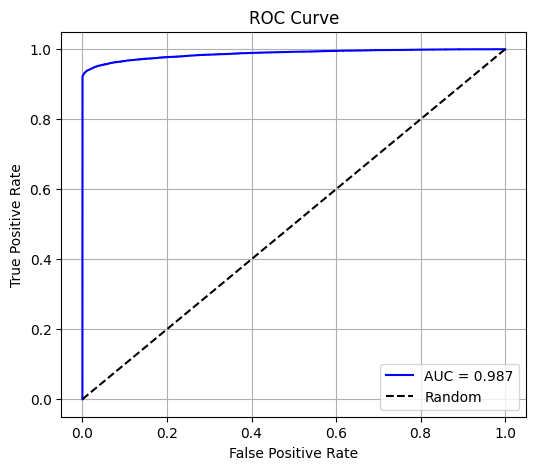

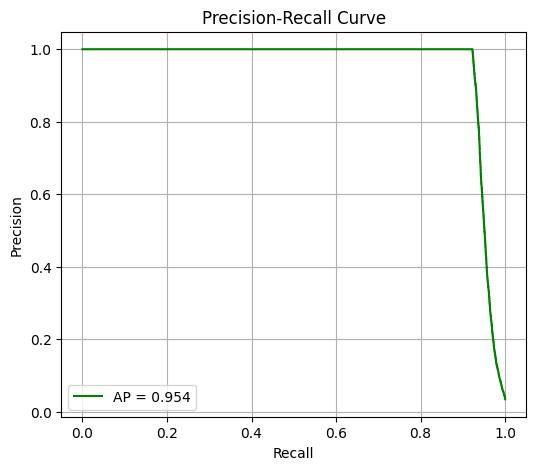

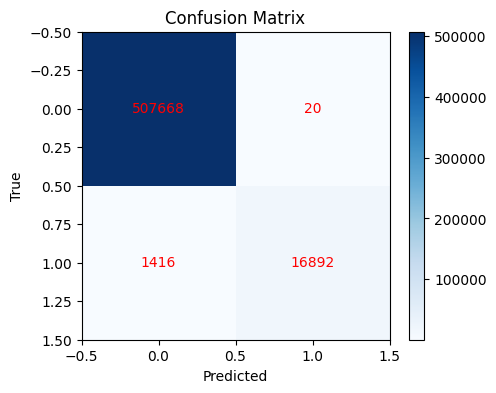

In [3]:
# ==== Next Cell: Plots & Classification Report ====
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
import numpy as np
import os

OUTPUT_DIR = "insider_output_lgb"  # ensure same as training cell

# Predictions
yval_prob = bst.predict(Xval, num_iteration=bst.best_iteration)
yval_pred = (yval_prob >= 0.5).astype(int)

# Classification Report
print("Classification Report:\n")
print(classification_report(yval, yval_pred))

# ROC AUC and Average Precision
auc = roc_auc_score(yval, yval_prob)
ap = average_precision_score(yval, yval_prob)
print(f"ROC AUC: {auc:.4f}, Average Precision: {ap:.4f}")

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(yval, yval_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="blue")
plt.plot([0,1],[0,1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"))
plt.show()

# ---- Precision-Recall Curve ----
precision, recall, _ = precision_recall_curve(yval, yval_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}", color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "pr_curve.png"))
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(yval, yval_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha='center', va='center', color="red")
plt.colorbar()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.show()


In [4]:
import joblib
import os

OUTPUT_DIR = "insider_output_lgb"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Save LightGBM model ----
model_path = os.path.join(OUTPUT_DIR, "lightgbm_email_model.txt")
bst.save_model(model_path)
print(f"✅ LightGBM model saved to {model_path}")

# ---- Save TF-IDF vectorizer ----
tfidf_path = os.path.join(OUTPUT_DIR, "tfidf_email_vectorizer.joblib")
joblib.dump(tfidf, tfidf_path)
print(f"✅ TF-IDF vectorizer saved to {tfidf_path}")


✅ LightGBM model saved to insider_output_lgb\lightgbm_email_model.txt
✅ TF-IDF vectorizer saved to insider_output_lgb\tfidf_email_vectorizer.joblib
